In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import pylab
from PIL import Image
from math import e
import astropy.io.fits as pf
from astropy.io import fits

## Load an image and apply an optional taper

(533, 400, 3)
(400, 400)


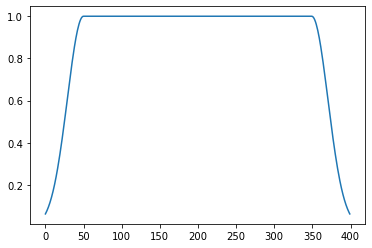

In [2]:
image = Image.open("Sorento.jpg")
image_arr = np.array(image)

x, y = np.meshgrid(np.linspace(-200,200,400), np.linspace(-200,200,400))
r = np.sqrt(x**2+y**2)

fwhm = 50.
taper = np.exp(-4*np.log(2)*((r-150)**2)/fwhm**2)
taper[np.where(r<=150)] = 1
plt.plot(taper[:,200])

print(image_arr.shape)
image_bw = image_arr[50:450,:,0]#*taper
#image_bw[200,200] = 5000
#image_bw[300,200] = 5000
#image_bw[200,350] = 5000
#image_bw[100,200] = 5000
print(image_bw.shape)


## Basic forward and inverse FFT test

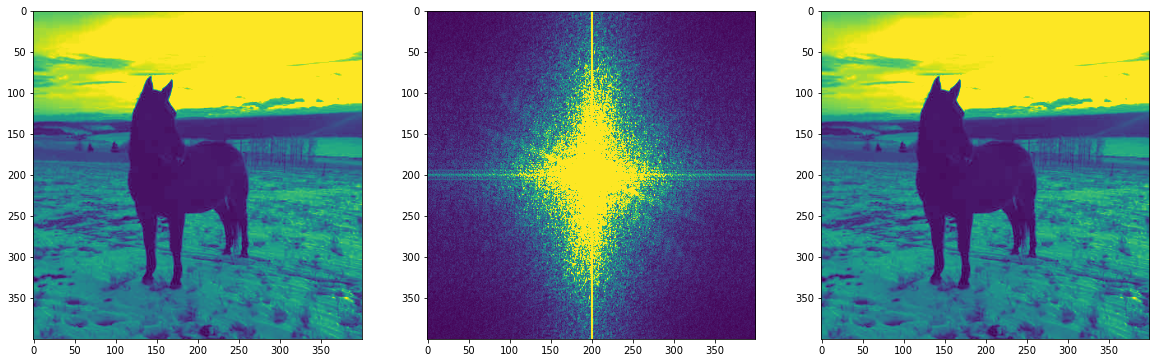

(150.0, 250.0)

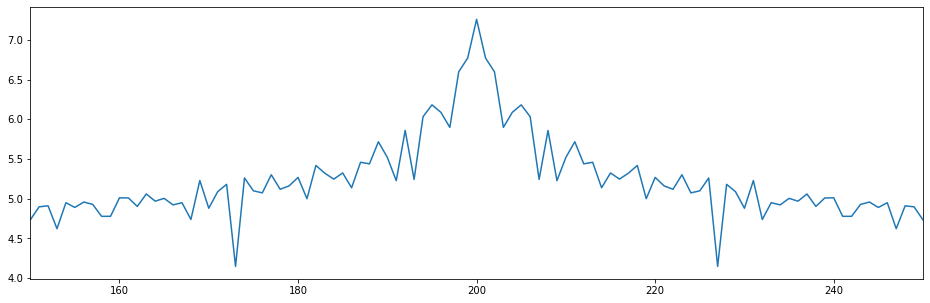

In [3]:
image_FFT = np.fft.fft2(image_bw)
image_FFT_shift = np.fft.fftshift(image_FFT)
image_IFFT = np.fft.ifft2(image_FFT_shift)

f = plt.figure(figsize=(20,20))
plt.subplot(131), plt.imshow(image_bw,vmin=0,vmax=200)
plt.subplot(132), plt.imshow(abs(image_FFT_shift),vmin=0,vmax=10000)
plt.subplot(133), plt.imshow(abs(image_IFFT),vmax=200)
plt.show()

fig,ax = plt.subplots(1,1,figsize=(16,5))
ax.plot(np.log10(abs(image_FFT_shift[:,200])))
ax.set_xlim(150,250)

## Test high, low and intermediate spatial filtering

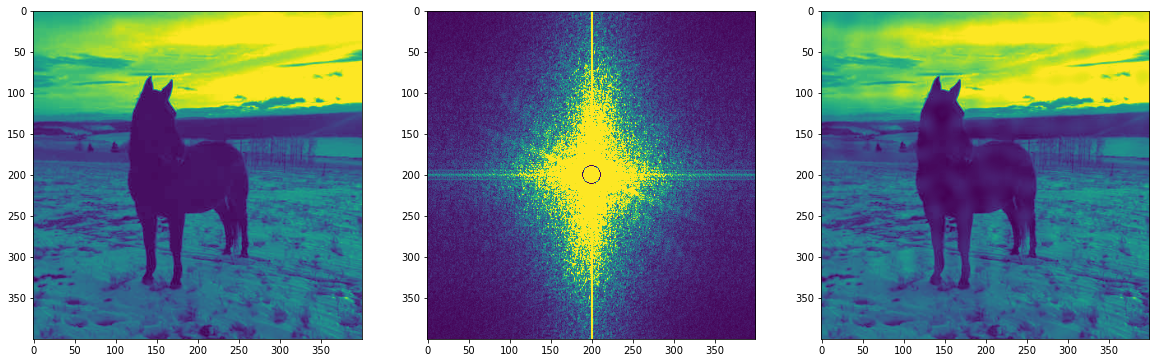

In [4]:
image_FFT = np.fft.fft2(image_bw)
image_FFT_shift = np.fft.fftshift(image_FFT)
image_IFFT = np.fft.ifft2(image_FFT_shift)
x, y = np.meshgrid(np.linspace(-200,200,400), np.linspace(-200,200,400))
r = np.sqrt(x**2+y**2)

r1 = 10
r2 = 12
#### Low-pass:
#w = np.where(r > r1)
#### High-pass:
#w = np.where(r < r1)
#### Missing baselines:
w = np.where((r > r1) & (r < r2))

image_FFT_shift[w]=0
image_IFFT = np.fft.ifft2(image_FFT_shift)
f = plt.figure(figsize=(20,20))
plt.subplot(131), plt.imshow(image_bw,vmin=0,vmax=250)
plt.subplot(132), plt.imshow(abs(image_FFT_shift),vmin=0,vmax=10000)#,plt.xlim(150,250),plt.ylim(150,250)
plt.subplot(133), plt.imshow(abs(image_IFFT),vmin=0,vmax=250)
plt.show()

## Spatial filtering with Gaussian tapers

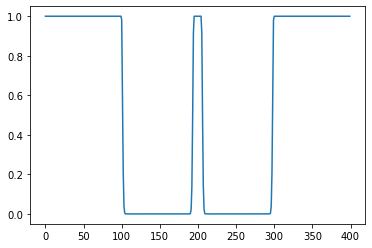

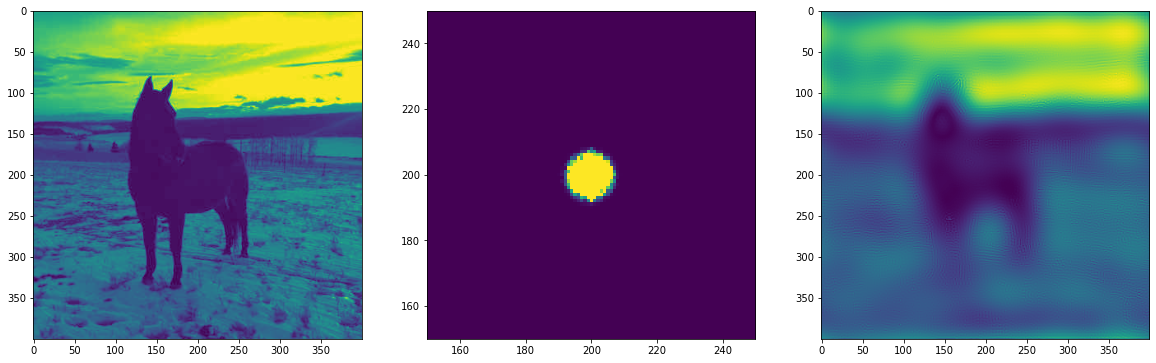

In [5]:
r1 = 5
r2 = 100

#mask1 = (1-np.exp(-4*np.log(2)*((r-r1)**2)/3**2))*2
#mask2 = (1-np.exp(-4*np.log(2)*((r-r2)**2)/3**2))*2
mask1 = np.exp(-4*np.log(2)*((r-r1)**2)/3**2)
mask2 = np.exp(-4*np.log(2)*((r-r2)**2)/3**2)
mask = mask1+mask2
mask[np.where(r<r1)] = 1
mask[np.where(r>r2)] = 1
plt.plot(mask[:,200])

image_FFT = np.fft.fft2(image_bw)
image_FFT_shift = np.fft.fftshift(image_FFT)*mask
image_IFFT = np.fft.ifft2(image_FFT_shift)

f = plt.figure(figsize=(20,20))
plt.subplot(131), plt.imshow(image_bw)
plt.subplot(132), plt.imshow(abs(image_FFT_shift),vmin=0,vmax=50000),plt.xlim(150,250),plt.ylim(150,250)
#plt.subplot(132), plt.imshow(mask)#,plt.xlim(150,250),plt.ylim(150,250)
plt.subplot(133), plt.imshow(abs(image_IFFT))
plt.show()

## Gaussian function for various purposes

In [6]:
def gf(mu,fwhm,x):
    return np.exp(-4*np.log(2)*((x-mu)**2)/fwhm**2)

## Mask to simulate CHIME uv-plane sampling

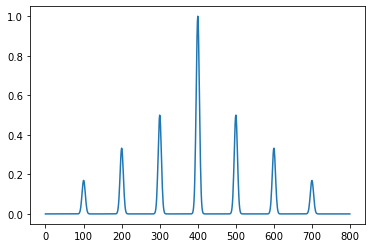

In [7]:
r1 = 0
r2 = 35
s = 10

x2, y2 = np.meshgrid(np.linspace(-400,400,800), np.linspace(-200,200,400))
mask = gf(0.5,s,x2)+0.5*gf(-99.5,s,x2)+0.5*gf(100.5,s,x2)+0.333*gf(-199.5,s,x2)+0.333*gf(200.5,s,x2)+0.17*gf(-299.5,s,x2)+0.17*gf(300.5,s,x2)
plt.plot(mask[200,:])
#plt.xlim(350,450)


## Check ring map procedure for single meridian slice

(400, 800)
(400, 800)


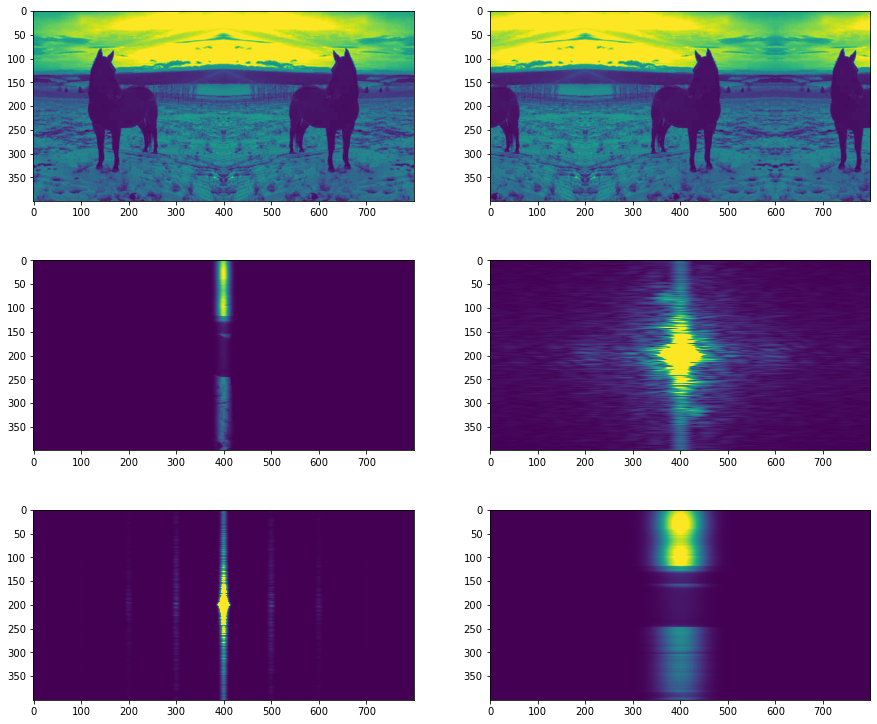

In [8]:
im_per = np.concatenate([image_bw,np.fliplr(image_bw)],axis=1)
print(im_per.shape)

i = 200
im_per_shift = np.concatenate([im_per[:,i:-1],im_per[:,0:i+1]],axis=1)
print(im_per_shift.shape)

im_per_FFT = np.fft.fftshift(np.fft.fft2(im_per_shift*gf(0,20,x2)))
im_per_IFFT = np.fft.ifft2(im_per_FFT*mask)

f = plt.figure(figsize=(15,13))
plt.subplot(321), plt.imshow(im_per,vmin=0,vmax=250)
plt.subplot(322), plt.imshow(im_per_shift,vmin=0,vmax=250)
plt.subplot(323), plt.imshow(im_per_shift*gf(0,20,x2),vmin=0,vmax=250)
plt.subplot(324), plt.imshow(abs(im_per_FFT),vmin=0,vmax=5000)
plt.subplot(325), plt.imshow(abs(im_per_FFT)*mask,vmin=0,vmax=5000)
plt.subplot(326), plt.imshow(abs(im_per_IFFT),vmin=0,vmax=60)
plt.show()

## Ring map procedure for full set of meridian slices

In [9]:
im_new = np.empty_like(im_per)

indices = np.array(np.concatenate([np.arange(0,400)[::-1],np.arange(400,800)[::-1]]))

for i in range(0,800):
    idx = indices[i]
    im_per_shift = np.concatenate([im_per[:,idx:-1],im_per[:,0:idx+1]],axis=1)*gf(0,20,x2)
    #print(i)
    im_per_FFT = np.fft.fftshift(np.fft.fft2(im_per_shift))*mask
    im_per_IFFT = np.fft.ifft2(im_per_FFT)
    im_new[:,i] = abs(im_per_IFFT[:,400])

    #im_per_IFFT = np.fft.ifft(im_per_FFT[:,400])
    #im_new[:,i] = -abs(im_per_IFFT)

## Compare before and after image ('sky' and ring map)

(<AxesSubplot:>, <matplotlib.image.AxesImage at 0x7fc91d553640>)

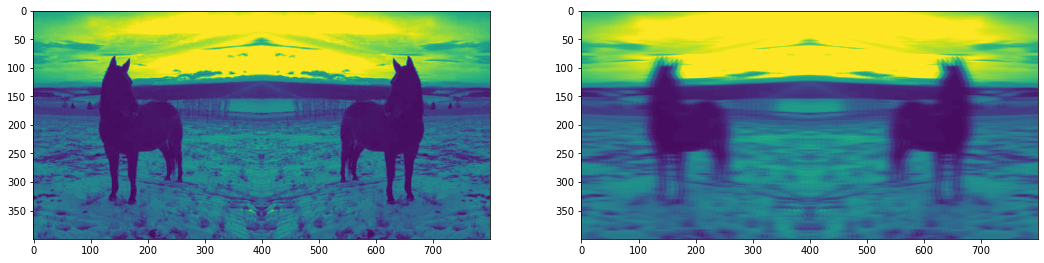

In [10]:
im_new_fix = np.empty_like(im_new)

for i in range(0,400):
    im_new_fix[i,:] = im_new[i,:]-np.nanmedian(im_new[i,:])
    
f = plt.figure(figsize=(18,10))
plt.subplot(121), plt.imshow(im_per,vmin=0,vmax=250)
plt.subplot(122), plt.imshow(im_new,vmin=0,vmax=60)

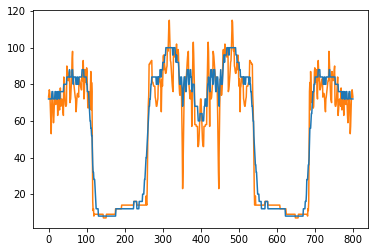

In [11]:
plt.plot(im_new[200,:]*4)
#plt.plot(im_new[200,:])
plt.plot(im_per[200,:],zorder=1)